# Expressing Multi-Head Attention

This notebook writes causal multi-head attention as a morphism and draws it as a neural circuit diagram. Each head computes the scaled dot-product attention of [Expressing Attention](Attention.ipynb) with a query, a key and a value of its own. The last cell writes the attention to a page.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.website.tutorial.express_attention as express_attention
import notebooks.website.tutorial.tutorial_pages as tutorial_pages
import notebooks.website.website_output as website_output

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    advanced_display=notebook_diagrams.AdvancedDisplay.LEGEND,
    operator_explanations=express_attention.OPERATOR_EXPLANATIONS,
    operator_references=express_attention.OPERATOR_REFERENCES,
    operator_roles=express_attention.MULTI_HEAD_ROLES,
    reindexing_explanations=express_attention.REINDEXING_EXPLANATIONS,
    title='Multi-Head Attention')
PAGE = dataclasses.replace(
    DIAGRAMS, mode=notebook_diagrams.DiagramMode.HTML,
    advanced_display=notebook_diagrams.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.TUTORIAL_PAGES)

MODEL = express_attention.multi_head_attention()
DISPLAYED = slide_causal_reads_backwards.slide_causal_reads_backwards(MODEL)

## Projecting every token into heads

$W^{Q}$, $W^{K}$ and $W^{V}$ project the state of each token into $|h|$ heads, each holding a query, a key and a value of $|d|$ channels, so each projection produces the two axes $h$ and $d$. $W^{O}$ reads the heads and the channels together and returns $|m|$ channels for each token. Section 3.2.2 of [Attention Is All You Need](https://arxiv.org/pdf/1706.03762v7) writes the result as the concatenation of the heads multiplied by $W^{O}$. A linear map of a concatenation is the sum of the maps of its parts, so the result is also the sum over the heads of each head's result multiplied by the rows of $W^{O}$ that belong to that head.

$$\mathrm{MultiHead}(z) = \sum_{i_{h} \in h} \mathrm{Attention}(z W^{Q}[i_{h}], z W^{K}[i_{h}], z W^{V}[i_{h}])\, W^{O}[i_{h}]$$

## Computing the attention once for every head

The $h$ wire crosses the dot product, the scale, the softmax and the weighted sum, so every operation of the scaled dot-product attention is broadcast over the heads. Each head therefore computes the attention of [Expressing Attention](Attention.ipynb) on its own, and the softmax normalises the scores of each head and each token separately. The keys and the values are read through the causal mask of [Expressing Attention with Weights and a Residual Connection](AttentionWithWeightsAndResidual.ipynb), and the figure draws the model in the CausalSlide form, with the mask at the copy of the state and $W^{K}$ and $W^{V}$ running over the tokens and the slots.

Multi-head attention in the CausalSlide form. The h wire crosses every operation of the scaled dot-product attention, and W^O reads the heads and the channels.


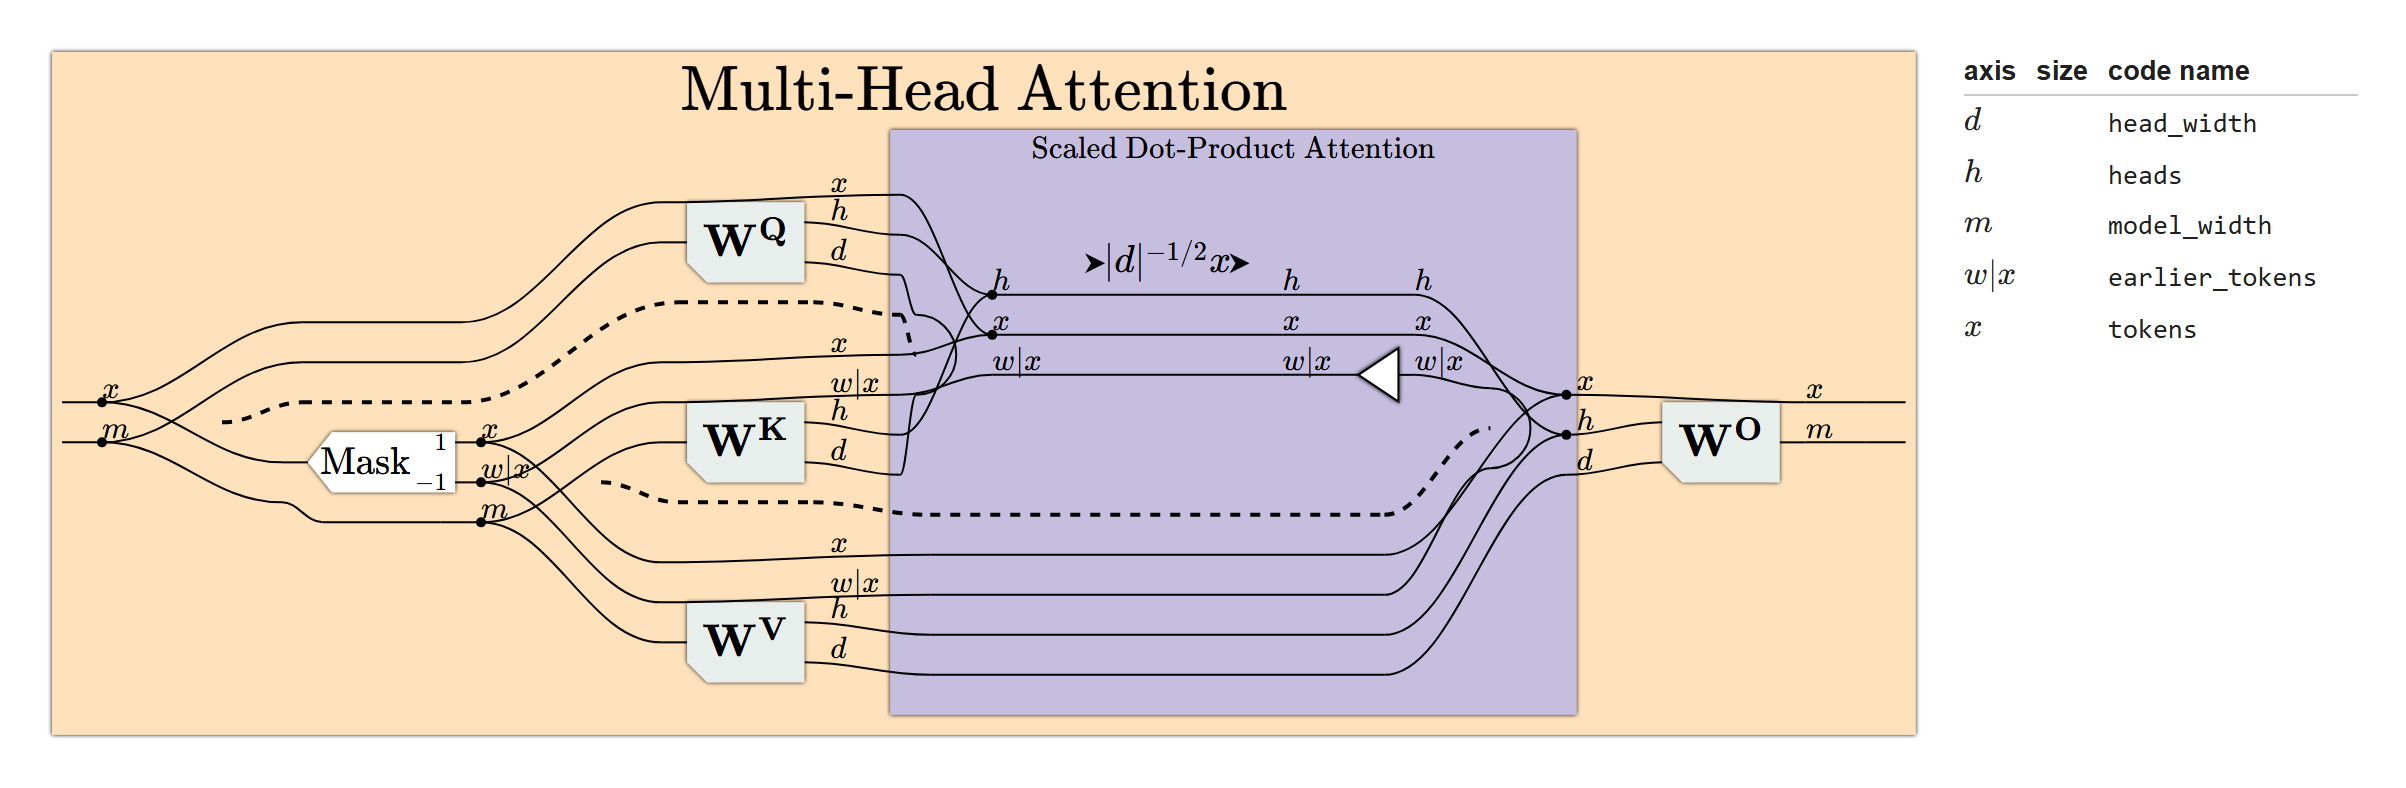

In [2]:
await notebook_diagrams.show_diagram(
    DISPLAYED,
    'Multi-head attention in the CausalSlide form. The h wire crosses every operation '
    'of the scaled dot-product attention, and W^O reads the heads and the channels.',
    width=1400, settings=DIAGRAMS)

## The interactive page

The last cell writes the attention to `notebooks/website/output/tutorial/MultiHeadAttention/index.html`, one file that opens with no server and no network. Resting the pointer on a block opens a box with its title, its formula and its description, resting it on a matrix opens the role of that matrix, and resting it on the mask opens the formula of the view.

In [3]:
await notebook_diagrams.show_page_variants(
    tutorial_pages.multi_head_attention_page(DISPLAYED, PAGE),
    'Multi-head attention as one HTML file.',
    settings=PAGE, slug=tutorial_pages.MULTI_HEAD_ATTENTION_SLUG,
    initial=tutorial_pages.FORWARD)

Multi-head attention as one HTML file.


(written to notebooks/website/output/tutorial/MultiHeadAttention/)
